In [1]:
year = 2023

In [2]:
from wind_wind.historical import get_generation, get_ARE_capacities

gen = get_generation(year)
cap = get_ARE_capacities(year)

historical_cf = gen/cap
historical_cf.name = f"Historical ({historical_cf.mean():.2%})"

In [3]:
historical_cf.mean()

np.float64(0.28222052874479997)

C:\coding\wind-wind\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:663: ArbitraryTypeWarning: <module 'sqlite3' from 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\\Lib\\sqlite3\\__init__.py'> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warnings.warn(


Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmpdetpy4gc
INFO:atlite.convert:Convert and aggregate 'wind'.


25.597
Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmpx0z25eue
INFO:atlite.convert:Convert and aggregate 'wind'.


34.156
Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmpk5wjaouy
INFO:atlite.resource:adding a cut-out wind speed to the turbine power curve at V=25.0 m/s.
INFO:atlite.convert:Convert and aggregate 'wind'.


36.74


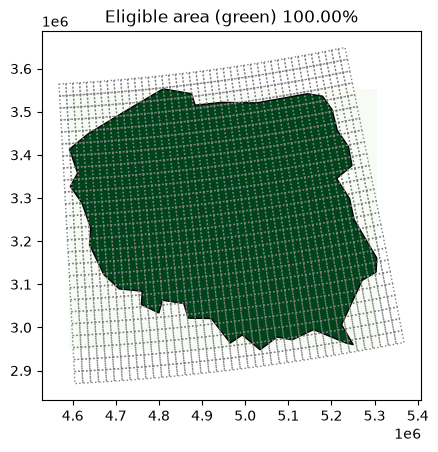

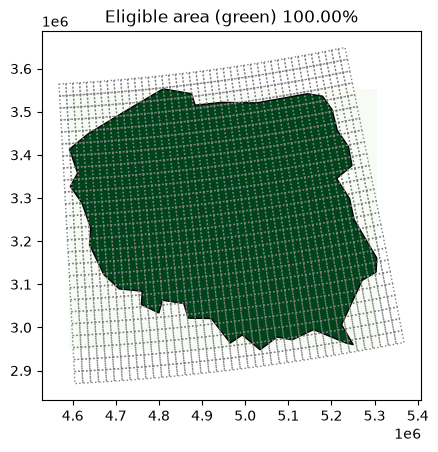

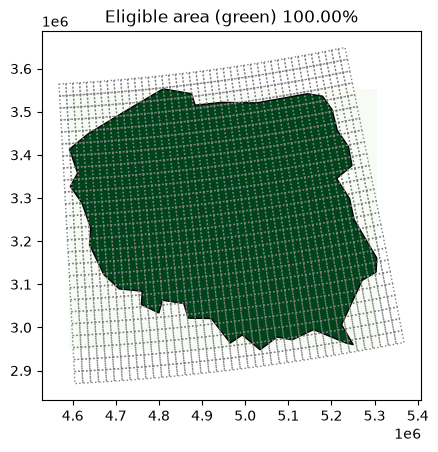

In [4]:
from wind_wind.profiles import Wind

cfs = []
profiles = []
for turbine_name in [
    "Vestas_V112_3MW",
    "2017COE_Market_Average_2.3MW_113",
    "IEA_Reference_3.4MW_130"
]:
    wind_profile = Wind(turbine_name=turbine_name, smooth=False, weather_year=year)
    wind_profile.generate()
    profile = wind_profile.profile
    profile.name = f"{turbine_name} ({profile.mean():.2%})"
    cfs.append(wind_profile.cf)
    profiles.append(profile)
    print(wind_profile.cf)


In [5]:
import pandas as pd
df = pd.concat([historical_cf, *profiles], axis=1)
df

,Historical (28.22%),Vestas_V112_3MW (25.60%),2017COE_Market_Average_2.3MW_113 (34.16%),IEA_Reference_3.4MW_130 (36.74%)
snapshot,,,,
2023-01-01 00:00:00,0.510692,0.951926,0.989019,0.990551
2023-01-01 01:00:00,0.375416,0.956298,0.988873,0.990467
2023-01-01 02:00:00,0.418898,0.957099,0.988780,0.990584
2023-01-01 03:00:00,0.511513,0.955202,0.987884,0.990196
2023-01-01 04:00:00,0.537454,0.942895,0.981431,0.985074
...,...,...,...,...
2023-12-31 19:00:00,0.406396,0.333433,0.477961,0.515435
2023-12-31 20:00:00,0.375298,0.317025,0.453185,0.489511
2023-12-31 21:00:00,0.363836,0.292259,0.418188,0.453658


<Axes: xlabel='snapshot'>

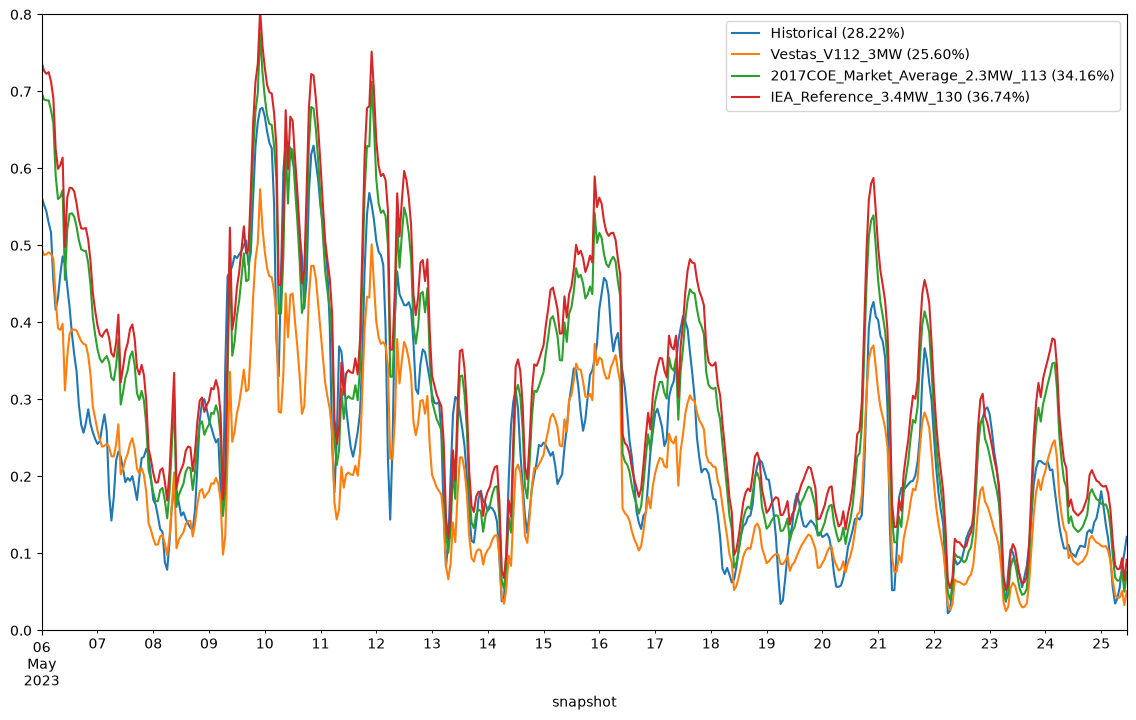

In [6]:
df[3000:3468].plot(figsize=(14,8), ylim=(0, 0.8))